# <font color="gree"><h1 align="center">LangGraph Crash Course</h1></font>

<font color="pink">Senior Data Scientist.: Dr. Eddy Giusepe Chirinos Isidro</font>


![](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSFcx8Gnmk4AFm2LBVBlTPm9evi8oaQ13HLHg&s)

Study link:

* [YouTube: The Neural Maze - Miguel Otero: LangGraph Crash Course](https://www.youtube.com/watch?v=05UXFERfdAQ&t=2472s)


LangGraph is a framework designed for building **complex, stateful LLM agent and multi-agent applications**.

Unlike traditional linear workflows, LangGraph uses a **graph-based architecture** that gives developers fine-grained control over agent behavior—enabling features like conditional logic, tool prioritization, looping, and shared memory.

It's ideal for creating **robust, production-ready AI systems** that require precision and adaptability.

The first thing we need to do, is to install a bunch of ``Python libraries`` we'll need throughout this crash course.

> Add blockquote



In [ ]:
#%%capture --no-stderr
#%pip install --quiet -U langchain_openai langchain_core langchain_community langgraph langchain-chroma

# <font color="red">Understanding LangGraph Structure</font>

Let's start by understanding the fundamental components of LangGraph and how to create a simple graph.


![](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQS_MHJ76eRGjs6qZCUE3yXvXCi3n64HmW-TQ&s)

Remember that LangGraph is based on three fundamental components: ``state``, ``nodes``, and ``edges``. Let's start with the state.

## <font color="blue">``1.`` State</font>

Start by defining the State of the graph.

This state schema acts as the input structure for all Nodes and Edges within the graph.

In [1]:
import getpass
import os

import bs4
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from typing_extensions import TypedDict


class State(TypedDict):
    graph_state: str


USER_AGENT environment variable not set, consider setting it to identify your requests.


## <font color="blue">``2.`` Nodes</font>

**Nodes are simply Python functions.**

Each node takes the state as its first positional argument, based on the previously defined `TypedDict` schema.

Since the state includes a `graph_state` key, each node can access it using `state['graph_state']`.

> Each node returns an updated value for graph_state, and by default, this new value will overwrite the existing one in the state.

In [2]:
def node_1(state):
    print("---Node 1---")
    return {"graph_state": state['graph_state'] +" Bem-vindo"}

def node_2(state):
    print("---Node 2---")
    return {"graph_state": state['graph_state'] +" ao DataHack Summit!"}

def node_3(state):
    print("---Node 3---")
    return {"graph_state": state['graph_state'] +" para Bengaluru!"}


## <font color="blue">``3.`` Edges</font>

Edges define the connections between nodes in the graph.

* **Normal edges** are used when you always want to transition from one node to another—for example, from `node_1` to `node_2`.

* **Conditional edges** allow for **dynamic routing** based on logic. These are implemented as functions that evaluate the current state and return the name of the next node to execute.

In [3]:
import random
from typing import Literal


def decide_node(state) -> Literal["node_2", "node_3"]:

    state['graph_state']

    if random.random() < 0.5:
        return "node_2"

    return "node_3"

## <font color="blue">``4.`` Graph Construction</font>

Now it's time to build the graph using the components we've defined.

We'll use the `StateGraph` class to create the graph structure.

First, initialize a `StateGraph` with the `State` schema we defined earlier.

> Then, add your nodes and connect them with edges.

Use the special `START` node to define the entry point of the graph—this is where user input enters the system.

The `END` node marks the terminal point where the graph finishes execution.

Once all nodes and edges are added, compile the graph to validate its structure.

You can also visualize the resulting graph as a **Mermaid diagram** for a clearer view of the workflow.

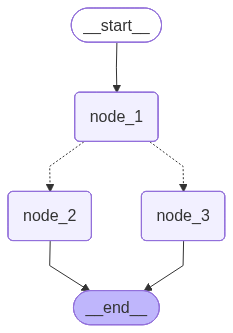

In [4]:
from IPython.display import Image, display
from langgraph.graph import END, START, StateGraph

# Build graph
builder = StateGraph(State)

# Defining the nodes
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# Logic - Defining the edges
builder.add_edge(START, "node_1")
builder.add_conditional_edges("node_1", decide_node)
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

# Compile the Graph
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

## <font color="blue">``5.`` Graph Execution</font>

The compiled graph conforms to the `Runnable` protocol, which defines a standard interface for executing LangChain components.

One of the key methods in this interface is `.invoke()`.

You start by passing an input dictionary, such as `{"graph_state": "Olá, aqui é o Eddy Giusepe!"}`, to set the initial value of the graph state.

When `.invoke()` is called, execution begins at the `START` node.

The graph then proceeds through the defined nodes (`node_1`, `node_2`, `node_3`), following the structure you built.

A conditional edge determines whether the flow goes from `node_1` to `node_2` or `node_3`, based on a 50/50 logic split.

Each node receives the current state, processes it, and returns an updated value, which replaces the previous graph_state.

Execution continues along the graph until the END node is reached, signaling completion.

In [5]:
graph.invoke({"graph_state" : "Olá, aqui é o Eddy Giusepe!"})

---Node 1---
---Node 2---


{'graph_state': 'Olá, aqui é o Eddy Giusepe! Bem-vindo ao DataHack Summit!'}

Congratulations, now we have an idea of how LangGraph works. Time to see what kind of LLM applications we can build with this framework!

# <font color="red">Building LLM Applications with LangGraph</font>

Our **Telegram Agent** will follow a pattern known as the **Router**, in which the LLM decides which workflow to follow.

**This Router is an evolution of static LLM Chains.**

Let's take a look at how to implement each one in the following sections.

> Don't forget about the Levels of Autonomy in LLM Applications! 👇


![](https://miro.medium.com/v2/resize:fit:1200/1*QLhWauRsxGblZUv3JDSQdQ.png)


## <font color="blue">Chains</font>

![](https://miro.medium.com/v2/da:true/resize:fit:1200/0*D-2coiGvZt5--33v)

Let's build a simple chain that combines 4 concepts:

* Using chat messages as our graph state
* Using chat models in graph nodes
* Binding tools to our chat model
* Executing tool calls in graph nodes

### <font color="yellow">``1.`` Messages</font>

Chat models can handle different types of messages representing various roles in a conversation. LangChain supports key message types like:

* `HumanMessage` - from the user
* `AIMessage` - from the chat model
* `SystemMessage` - to guide the model's behavior
* `ToolMessage` - responses from tool calls

Let's build a list of messages. Each message can include:

* **content** - the message text
* **name** - optional author name
* **response_metadata** - optional metadata (e.g. from model providers for AIMessage, like ``OpenAI``)


In [8]:
from textwrap import dedent

from langchain_core.messages import AIMessage, HumanMessage

messages = [AIMessage(content=dedent("""Olá, sou o assistente virtual para o podcast 'My Data Guest'.
                                        Como posso ajudar?
                                     """
                                    ),
            name="Agent")
           ]

messages.append(HumanMessage(content="Quero saber mais sobre Rosaria Silipo", name="Miguel"))

for m in messages:
    m.pretty_print()


================================== Ai Message ==================================
Name: Agent

Olá, sou o assistente virtual para o podcast 'My Data Guest'.
                                        Como posso ajudar?
================================ Human Message =================================
Name: Miguel

Quero saber mais sobre Rosaria Silipo


### <font color="yellow">Chat Models</font>

Chat models accept a sequence of messages as input and support multiple message types, as previously mentioned.

Among the available options, we'll be working with **OpenAI**.

Before proceeding, we'll check if your `OPENAI_API_KEY` is configured. If it's not, you'll be prompted to provide it.

In [9]:
def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("OPENAI_API_KEY")

In [12]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4.1", temperature=0.0)
result = llm.invoke(messages)

We can see that the result is an `AIMessage` with specific `response_metadata`.

In [13]:
type(result)

langchain_core.messages.ai.AIMessage

In [14]:
result.content

'Claro! Rosaria Silipo é uma cientista de dados, autora e palestrante reconhecida internacionalmente, especialmente na área de machine learning e inteligência artificial. Ela é PhD em Engenharia Eletrônica e tem mais de 25 anos de experiência em ciência de dados, análise de dados e desenvolvimento de soluções baseadas em IA.\n\nAtualmente, Rosaria Silipo é Principal Data Scientist na KNIME, uma plataforma open source de análise de dados, onde lidera projetos, escreve tutoriais, livros e ministra workshops sobre ciência de dados. Ela é autora do livro **"KNIME Beginner’s Luck"** e coautora de outros materiais didáticos sobre machine learning e data science.\n\nAlém disso, Rosaria é conhecida por sua habilidade em explicar conceitos complexos de forma acessível, sendo presença frequente em conferências, podcasts e eventos da área. Ela também compartilha conhecimento em seu blog e no canal da KNIME, abordando temas como deep learning, processamento de linguagem natural, visualização de da

### <font color="yellow">Tools</font>



Tools are valuable when you need a model to interact with **external systems**.

These systems (such as APIs) typically expect **structured inputs** rather than natural language.

> By binding an API as a tool, you make the model aware of the expected input format.


The model decides when to call a tool based on the user's natural language input, and the output will follow the tool's defined schema.

Many LLM providers now support tool calling, and LangChain offers a straightforward interface for it.

You can bind any Python function using `ChatModel.bind_tools(function)`.




![](https://cdn.analyticsvidhya.com/wp-content/uploads/2024/10/image-88.webp)

Let's showcase a very simple example of tool calling. The `multiply` function is our tool.

In [15]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

llm_with_tools = llm.bind_tools([multiply])

In [16]:
no_tool_call = llm_with_tools.invoke(
    [HumanMessage(content="Olá! Como você está?", name="Miguel")]
)

In [17]:
no_tool_call.pretty_print()

================================== Ai Message ==================================

Olá, Miguel! Estou bem, obrigado por perguntar. E você, como está? Em que posso te ajudar hoje?


In [18]:
no_tool_call.content

'Olá, Miguel! Estou bem, obrigado por perguntar. E você, como está? Em que posso te ajudar hoje?'

In [20]:
tool_call = llm_with_tools.invoke(
    [HumanMessage(content="Qual é o produto de 2 e 3?", name="Miguel")]
)


We can see a tool call return.

>The tool call has specific arguments that match the input schema of our function along with the name of the function to call.

In [21]:
tool_call.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  multiply (call_2G2q28myBlN0jcgIoCMQvcym)
 Call ID: call_2G2q28myBlN0jcgIoCMQvcym
  Args:
    a: 2
    b: 3


In [22]:
tool_call.content

''

In [23]:
tool_call.tool_calls

[{'name': 'multiply',
  'args': {'a': 2, 'b': 3},
  'id': 'call_2G2q28myBlN0jcgIoCMQvcym',
  'type': 'tool_call'}]

### <font color="yellow">Defining the State</font>

Unlike the example graph we saw earlier, in this case we need to use `messages` (the message history) within the state.

If we wanted to handle this manually, we'd need to create another `TypedDict` with a messages property.

In [24]:
from langchain_core.messages import AnyMessage
from typing_extensions import TypedDict


class MessagesState(TypedDict):
    messages: list[AnyMessage]

Fortunately, LangGraph already provides a built-in state type for this: `MessagesState`.

The cool thing about this class is that it already incorporates a `reducer`. This reducer logic will take care of appending the new message to the message list.

> All of these operations will be perform by LangGraph under the hood

In [25]:
class MessagesState(MessagesState):
    pass

### <font color="yellow">Building the Graph</font>

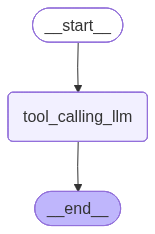

In [26]:
from IPython.display import Image, display
from langgraph.graph import END, START, StateGraph


# Node
def tool_calling_llm(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(MessagesState)

builder.add_node("tool_calling_llm", tool_calling_llm)

builder.add_edge(START, "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)

graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

We've implemented a very simple chain!

If we pass a general message (unrelated to math operations), the LLM will respond without any tool call.

In [28]:
messages = graph.invoke({"messages": [HumanMessage(content="Olá! Eu sou o Eddy Giusepe")]})

for m in messages['messages']:
    m.pretty_print()

================================== Ai Message ==================================

Olá, Eddy Giusepe! Como posso ajudar você hoje?


But, if we ask about a multiplication, the LLM will use our tool.

In [30]:
messages = graph.invoke({"messages": [HumanMessage(content="Multiplique 10 e 3")]})

for m in messages['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  multiply (call_VvvugpaXSJHvYEa2NX3OqLYb)
 Call ID: call_VvvugpaXSJHvYEa2NX3OqLYb
  Args:
    a: 10
    b: 3


---

## <font color="blue">Router</font>

You can think of this as a **router**, where the chat model decides—based on user input—whether to respond directly or to call a tool.

This represents a basic form of an agent, where the LLM manages control flow by choosing between tool invocation and generating a direct reply.

<img src="https://drive.google.com/uc?id=18D4oguG3jAxr9GoQJcHZUevxcEdudkHh" alt="Alt text" width="700"/>


Let's extend the Chain example (the tool calling chain) like this:

(1) Add a node that will call our tool

(2) Add a conditional edge that will look at the chat model output, and route to our tool calling node or simply end if no tool call is performed

In [ ]:
from langchain_openai import ChatOpenAI


def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

llm = ChatOpenAI(model="gpt-4o")
llm_with_tools = llm.bind_tools([multiply])

 We use the built-in `ToolNode` and simply pass a list of our tools to initialize it.

 We use the built-in `tools_condition` as our conditional edge.

In [ ]:
from IPython.display import Image, display
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition


# Node
def tool_calling_llm(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(MessagesState)

builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode([multiply]))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", END)

graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
from langchain_core.messages import HumanMessage

messages = [HumanMessage(content="Hello, what is 2 multiplied by 2?")]
messages = graph.invoke({"messages": messages})
for m in messages['messages']:
    m.pretty_print()

---

## ReAct Agent

<img src="https://drive.google.com/uc?id=1HSQUzZAkCv_Ec-1EES1yZZFCPKizISsW" alt="Alt text" width="700"/>

The ReAct pattern is one of the most common for agentic architectures. It's the one we'll be using for our Telegram Bot as well.

You can think of it as an evolution of the Router pattern.

In the router above, we invoked the model — and if it decided to call a tool, we returned a ToolMessage to the user.

But what if, instead, we passed that ToolMessage back to the model?


That way, it gets to decide what's next:

(1) **Call another tool**

(2) **Respond directly**

ReAct stands for "Reason + Act", and can be easily understood by the following diagram.

<img src="https://drive.google.com/uc?id=1BfpjPboaDU0fJ1dtuuBuVhjZxRlVDJB1" alt="Alt text" width="700"/>

To test how the ReAct architecture works, let's create three tools instead of one.

In [ ]:
from langchain_openai import ChatOpenAI


def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools = [add, multiply, divide]

Now, let's bind the three tools to the OpenAI ChatModel.

In [ ]:
llm = ChatOpenAI(model="gpt-4o")
llm_with_tools = llm.bind_tools(tools, parallel_tool_calls=False)

Let's create a simple node for defining the assistant behaviour.

In [ ]:
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import MessagesState

sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic operations")


def assistant(state: MessagesState):
  return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

Finally, let's build and compile the graph.

In [ ]:
from IPython.display import Image, display
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition

builder = StateGraph(MessagesState)

builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    tools_condition,
)

# IMPORTANT! -> Now the 'tools' node points back to the 'assistant' node, creating a loop
builder.add_edge("tools", "assistant")
react_graph = builder.compile()

display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

Let's try it out ...

In [ ]:
messages = [HumanMessage(content="Add 10 and 5. Multiply the output by 2. Divide the output by 5")]
messages = react_graph.invoke({"messages": messages})

In [ ]:
for m in messages['messages']:
  m.pretty_print()

## Adding short-term memory

Let's try something. First, we are going to invoke our graph:

In [ ]:
messages = [
    HumanMessage(content="Hello, I'm Miguel!")
]

messages = graph.invoke({"messages": messages})

for m in messages['messages']:
  m.pretty_print()

But ... what happens if I ask my name again?

In [ ]:
messages = [
    HumanMessage(content="Remember my name?")
]

messages = graph.invoke({"messages": messages})

for m in messages['messages']:
    m.pretty_print()

Did you guess it?

Memory is not working for this Graph! This is because state is transient to a single graph execution.

Of course, this limits our ability to have multi-turn conversations with interruptions.

We can use persistence to address this!

LangGraph can use a checkpointer to automatically save the graph state after each step.

This built-in persistence layer gives us memory, allowing LangGraph to pick up from the last state update.

One of the easiest checkpointers to use is the MemorySaver, an in-memory key-value store for Graph state.

All we need to do is simply compile the graph with a checkpointer, and our graph has memory!

In [ ]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()
graph_memory = builder.compile(checkpointer=memory)

When we use memory, we need to specify a thread_id.

This thread_id will store our collection of graph states.

* The checkpointer write the state at every step of the graph
* These checkpoints are saved in a thread
* We can access that thread in the future using the thread_id


Check the image below! 👇

<img src="https://drive.google.com/uc?id=15myCwBmiCAfnHqnMAO3IvToXpNBsG6vm" alt="Alt text" width="1000"/>

Let's try again defining a thread_id for our interaction.

In [ ]:
# Specify a thread
config = {"configurable": {"thread_id": "1"}}

messages = [
    HumanMessage(content="Hello, my name is Miguel!")
]

# The difference from before is that now we need to pass the config
messages = graph_memory.invoke({"messages": messages}, config)

for m in messages['messages']:
  m.pretty_print()

Let's see if the assistant remembers us now ...

In [ ]:
messages = [HumanMessage(content="Hey, can you say my name? Do you remember it?")]

messages = graph_memory.invoke({"messages": messages}, config)

for m in messages['messages']:
  m.pretty_print()

Adding the checkpointer fixes the issue! Our Graph has memory now!

## Adding long-term memory (Vector Database)

Now that the short-term memory is ready, it's time to implement the long-term memory.

We'll use this long-term memory as a way to store external information (PDFs, articles, etc.). How? By using a Vector Database: Chroma DB.

## Indexing

<img src="https://drive.google.com/uc?id=1NgGD7Vt1-gLhlC-bMVY0vGhPyNZxamgX" alt="Alt text" width="800"/>


The first thing we'll do is to download documents from a source and index them, using ChromaDB. The first thing to do, is to instantiate the Chroma instance.

In [ ]:
from langchain_chroma import Chroma
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-large")
llm = ChatOpenAI(model="gpt-4o")


vector_store = Chroma(
    collection_name="example_collection",
    embedding_function=embeddings,
    persist_directory="longterm_memory_db",
)

Then we are going to download one of [my Data Guest articles](https://mydataguest.substack.com/p/how-chatgpt-speaks-so-many-languages) and apply the character splitter. This will split the document into multiple chunks.

In [ ]:

loader = WebBaseLoader(
    web_paths=("https://mydataguest.substack.com/p/how-chatgpt-speaks-so-many-languages/",),
    bs_kwargs={
        "parse_only": bs4.SoupStrainer(
            class_=("available-content", "post-title", "post-header")
        )
    },
)
docs = loader.load()

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
all_splits = text_splitter.split_documents(docs)

Now, we can explore the first chunk of our list.

In [ ]:
all_splits[0]

The final step, is to index the chunks!

In [ ]:
_ = vector_store.add_documents(documents=all_splits)

### Retrieval

<img src="https://drive.google.com/uc?id=15syVDH5hSHOpRZJFR2xcEweBmXNc2Wn_" alt="Alt text" width="800"/>

Now that all the chunks are indexed, we need a way to access the information stored in Chroma. Of course, we could query directly, like this:

In [ ]:
results = vector_store.similarity_search(
    "Emergent Behavior",
    k=1,
)

In [ ]:
results

In [ ]:
from langchain_core.tools.retriever import create_retriever_tool

retriever = vector_store.as_retriever(search_kwargs={"k": 2})

retriever_tool = create_retriever_tool(
    retriever=retriever,
    name="retrieve_article_info_tool",
    description="Retrieve some information from Rosaria Silipo's article",
)

In [ ]:
retriever.invoke("What are the three main approaches to tokenization?")

In [ ]:
retriever_tool.invoke("What are the three main approaches to tokenization?")

Now, we need to add this retriever as a Tool to our graph. That's very easy if you use the ToolNode class.

This is the final version of our ReAct Agent with short-term and long-term memories.

In [ ]:
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition

llm_with_tool = llm.bind_tools([retriever_tool])
memory = MemorySaver()


# Node
def assistant(state: MessagesState):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}

# Build graph
workflow = StateGraph(MessagesState)

# Add nodes
workflow.add_node("assistant", assistant)
workflow.add_node("tools", ToolNode([retriever_tool]))

workflow.add_edge(START, "assistant")
workflow.add_conditional_edges(
    "assistant",
    tools_condition,
)
workflow.add_edge("tools", "assistant")

# Compile the graph
graph = workflow.compile(checkpointer=memory)

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
# Specify a thread
config = {"configurable": {"thread_id": "1"}}

messages = [
    HumanMessage(content="What are the three main approaches to tokenization?")
]

# The difference from before is that now we need to pass the config
messages = graph.invoke({"messages": messages}, config)

for m in messages['messages']:
  m.pretty_print()